# Fox vision → validation: does the model generalize to an unseen world?

`train_model.ipynb` fit **`foxvision.pth`** on scenes drawn from **world seed 12345** (run
seed 7). This notebook is the honest test: build a **different** world (a new world seed) with
**different** dynamics (a new run seed), synthesize a fresh *small* test set with the **same**
real perception → `RuleBrain` pipeline, then score the **saved** model on it.

If accuracy holds on terrain the model never saw in training, it learned to *follow the
sheep* — not to memorize one map. Nothing in `sim/` is modified; it is only imported, exactly
as in `generate_dataset.ipynb`.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Make the ecosystem package importable no matter which directory the kernel started in.
_here = Path.cwd()
REPO = next((c for c in [_here, *_here.parents]
             if (c / "config.py").exists() and (c / "sim").is_dir()), _here)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from config import make_config, SHEEP, FOX
from sim.world import World
from sim.environment import Environment
from sim.entities import Entities
from sim.grid import SpatialGrid
from sim.perception import Perception, FX_TERRAIN, FX_FOOD
from sim.brain import RuleBrain, A_DX, A_DY
from sim.systems import vegetation
from sim import genome as gn

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("repo:", REPO, "| device:", device)

repo: c:\Users\afree\Desktop\ecosystem | device: cuda


## 1. A brand-new world + fresh dynamics

The **only** things that change from training are the seeds:

* **`VAL_WORLD_SEED`** — a different map (terrain + rivers). Training used `12345`.
* **`VAL_RUN_SEED`** — different dynamics. Training used `7`.
* **`VAL_GEN_SEED`** — samples different fox/sheep layouts.

The perception geometry is kept **identical** to training — fox eye radius **12** cells,
cropped to a **25×25** window — because the saved CNN was trained on exactly that view.

In [2]:
# --- validation parameters (deliberately DIFFERENT from training) ----------
VAL_WORLD_SEED = 54321      # training used 12345 -> a map the model never saw
VAL_RUN_SEED   = 99         # training used 7
VAL_GEN_SEED   = 31337      # scenario sampling (fresh fox/sheep layouts)

FOX_SENSORY = 12.0          # MUST match training (the CNN saw 25x25 crops of a 12-cell eye)
CROP_R      = 12
WIN         = 2 * CROP_R + 1                       # -> 25 x 25
N_SCENARIOS = 250           # a small test set

POS_TOL    = np.radians(20.0)   # within this of the true heading -> label 1
NEG_MARGIN = np.radians(45.0)   # beyond this from the true heading -> label 0
N_POS_JITTER = 1

MODEL_PATH = REPO / "notebooks" / "vision" / "fox" / "foxvision.pth"

# --- build the headless world + the pieces perception needs (mirrors generator) ---
cfg   = make_config(world_seed=VAL_WORLD_SEED, seed=VAL_RUN_SEED)
world = World(cfg.world)
env   = Environment(cfg.env, np.random.default_rng(11))
ent   = Entities(cfg)
veg   = vegetation.initial_field(world, np.random.default_rng(22))
temp_field = env.temperature_field(world.static_temp)

grids = {SHEEP: SpatialGrid(world.w, world.h, cfg.sim.grid_cell_size),
         FOX:   SpatialGrid(world.w, world.h, cfg.sim.grid_cell_size)}
perc  = Perception(cfg, world, ent, env)
brain = RuleBrain(np.random.default_rng(33), cfg.sim.food_eat_threshold)

# candidate cells: passable, dry, and NOT forest cover (covered sheep are invisible to foxes).
land_mask = world.passable & ~world.water_any & ~world.cover
land_ys, land_xs = np.nonzero(land_mask)

sheep_spec, fox_spec = cfg.species[SHEEP], cfg.species[FOX]
S_IDX = gn.GENE_INDEX["sensory_range"]
print(f"validation world seed {VAL_WORLD_SEED}, run seed {VAL_RUN_SEED}")
print(f"perception window K={perc.K}; stored crop {WIN}x{WIN}; land cells={land_xs.size}")

validation world seed 54321, run seed 99
perception window K=57; stored crop 25x25; land cells=13138


## 2. One scenario = one perception → true heading

Identical to the generator: clear the world, place **one hungry fox** + **one sheep** inside
the eye disc, then run the real perception + `RuleBrain` to get the **true** heading (straight
at the sheep). The fox is made hungry so the `RuleBrain` commits to the prey rather than
wandering.

In [3]:
def rebuild_grids():
    for sid, g in grids.items():
        sidx = np.nonzero(ent.species_mask(sid))[0]
        g.rebuild(sidx, ent.pos_x, ent.pos_y)


def make_scenario(rng):
    """Place ONE fox + ONE sheep in vision range; run perception -> RuleBrain."""
    ent.kill(ent.alive_indices())                       # fresh, empty world

    for _ in range(200):
        k = int(rng.integers(0, land_xs.size))
        fx, fy = land_xs[k] + 0.5, land_ys[k] + 0.5
        dist   = rng.uniform(2.0, FOX_SENSORY - 1.0)
        ang    = rng.uniform(0.0, 2 * np.pi)
        sx, sy = fx + dist * np.cos(ang), fy + dist * np.sin(ang)
        scx, scy = int(sx), int(sy)
        if not (0 <= scx < world.w and 0 <= scy < world.h):
            continue
        if world.cover[scy, scx] or world.water_any[scy, scx]:
            continue
        break
    else:
        return None

    sg = gn.random_genomes(sheep_spec, 1, rng)
    fg = gn.random_genomes(fox_spec, 1, rng)
    fg[0, S_IDX] = FOX_SENSORY
    ent.spawn(sheep_spec, sg, np.array([[sx, sy]], np.float32), rng,
              energy=0.8, age=np.float32(sheep_spec.maturity_age * 2))
    fox_slot = int(ent.spawn(fox_spec, fg, np.array([[fx, fy]], np.float32), rng,
                             energy=0.5, age=np.float32(fox_spec.maturity_age * 2))[0])

    ent.hunger[fox_slot] = 0.75    # hungry fox -> RuleBrain locks onto the prey
    ent.thirst[fox_slot] = 0.05
    ent.energy[fox_slot] = 0.50

    rebuild_grids()
    perc._species_grids = grids
    perc.veg = veg
    perc.temp_field = temp_field
    obs_by_species, idx = perc.build()
    act = brain.decide(obs_by_species, idx)

    fgrids = obs_by_species[FOX].grids[0]               # (4, K, K)
    R = perc.R
    sl = slice(R - CROP_R, R + CROP_R + 1)
    terrain = fgrids[FX_TERRAIN, sl, sl].astype(np.float32).copy()
    entity  = fgrids[FX_FOOD,    sl, sl].astype(np.float32).copy()

    row = int(np.searchsorted(idx, fox_slot))
    dx, dy = float(act[row, A_DX]), float(act[row, A_DY])
    meta = dict(sheep_dx=sx - fx, sheep_dy=sy - fy, dist=float(dist),
                entity_cells=int((entity > 0).sum()))
    return terrain, entity, dx, dy, meta


def candidate_headings(true_ang, rng):
    """(angle, label): the true heading (+jitter) and a spread of wrong ones."""
    cands = [(true_ang, 1)]
    for _ in range(N_POS_JITTER):
        cands.append((true_ang + rng.uniform(-POS_TOL, POS_TOL), 1))
    s = 1.0 if rng.random() < 0.5 else -1.0
    offsets = [s*np.radians(90), -s*np.radians(135), np.radians(180),
               s*rng.uniform(NEG_MARGIN, np.radians(180))]
    cands += [(true_ang + off, 0) for off in offsets]
    return cands

## 3. Synthesize the fresh test set

For each scene we keep one 2-channel view (the model's input) plus the true toward-sheep
heading (the regression target), and a set of **labelled candidate headings** (true vs
sideways / oblique / opposite / random) for a classification-style check.

In [4]:
rng = np.random.default_rng(VAL_GEN_SEED)
views, toward = [], []                       # per-scene: 2-ch view, unit heading to sheep
c_scene, c_dx, c_dy, c_lab = [], [], [], []  # per-candidate: scene id, heading, label
made = attempts = 0
while made < N_SCENARIOS:
    attempts += 1
    out = make_scenario(rng)
    if out is None:
        continue
    terrain, entity, dx, dy, meta = out
    if meta["entity_cells"] == 0 or (dx == 0.0 and dy == 0.0):
        continue                             # sheep not perceived -> skip
    views.append(np.stack([terrain, entity], axis=0))
    tw = np.array([meta["sheep_dx"], meta["sheep_dy"]], np.float32)
    toward.append(tw / (np.linalg.norm(tw) + 1e-9))
    true_ang = np.arctan2(dy, dx)
    for a, label in candidate_headings(true_ang, rng):
        c_scene.append(made); c_lab.append(label)
        c_dx.append(np.cos(a)); c_dy.append(np.sin(a))
    made += 1

X       = np.asarray(views, np.float32)           # (S, 2, WIN, WIN)
toward  = np.asarray(toward, np.float32)          # (S, 2) unit toward-sheep
cand    = np.stack([np.asarray(c_dx, np.float32),
                    np.asarray(c_dy, np.float32)], axis=1)   # (C, 2) unit headings
cand_scene = np.asarray(c_scene, np.int64)
cand_lab   = np.asarray(c_lab, np.int64)
print(f"{made} scenes ({attempts} attempts) | X {X.shape} | candidates {cand.shape[0]}")
print("label balance:", dict(zip(*np.unique(cand_lab, return_counts=True))))

250 scenes (250 attempts) | X (250, 2, 25, 25) | candidates 1500
label balance: {np.int64(0): np.int64(1000), np.int64(1): np.int64(500)}


## 4. Load the saved model

The architecture must match `train_model.ipynb` byte-for-byte to load the weights. We put it
in eval mode and never touch its parameters — this is pure inference on the unseen world.

In [5]:
class FoxVisionNet(nn.Module):
    """CNN over the 2-channel view -> FNN -> the (dx, dy) heading (matches train_model)."""
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(2, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(6),
            nn.Flatten(),
        )
        self.fnn = nn.Sequential(
            nn.Linear(32*6*6, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 2),
        )
    def forward(self, grid):
        return self.fnn(self.cnn(grid))


def unit(v):
    return v / (v.norm(dim=1, keepdim=True) + 1e-9)

model = FoxVisionNet().to(device)
state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()
print("loaded:", MODEL_PATH.name, "|", sum(p.numel() for p in model.parameters()), "params")

loaded: foxvision.pth | 170162 params


## 5. Accuracy — does the output heading point at the sheep?

The model's output **is** the `(dx, dy)` move heading. On the unseen world we compare it to
the true direction to the sheep: cosine similarity (→ +1 is perfect), the fraction of scenes
within 20° (a tight "correct direction" bar), and the median angular error.

unseen world seed 54321 | held-out scenes: 250
mean cosine(pred, toward-sheep): +0.996
within 20 deg of sheep:          99.2%
within 45 deg of sheep:          100.0%
median heading error:            2.6 deg


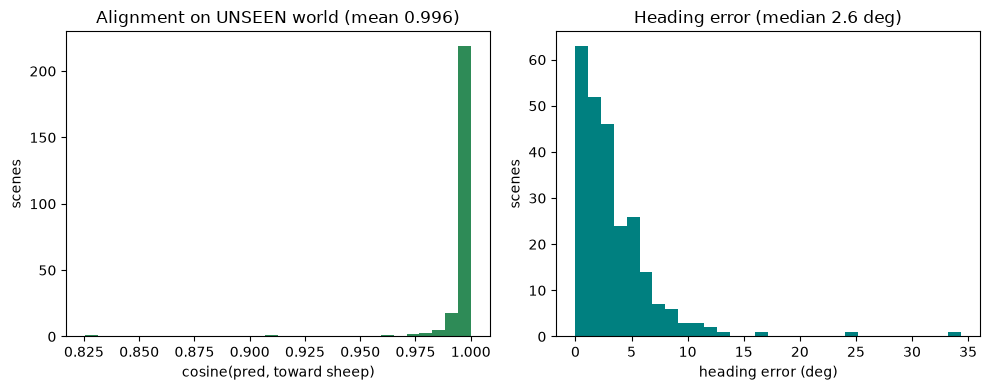

In [6]:
with torch.no_grad():
    pred = unit(model(torch.tensor(X).to(device))).cpu().numpy()   # (S, 2) predicted heading

cos = (pred * toward).sum(1)
ang = np.degrees(np.arccos(np.clip(cos, -1, 1)))
print(f"unseen world seed {VAL_WORLD_SEED} | held-out scenes: {len(pred)}")
print(f"mean cosine(pred, toward-sheep): {cos.mean():+.3f}")
print(f"within 20 deg of sheep:          {np.mean(ang <= 20)*100:.1f}%")
print(f"within 45 deg of sheep:          {np.mean(ang <= 45)*100:.1f}%")
print(f"median heading error:            {np.median(ang):.1f} deg")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(cos, bins=30, color="seagreen")
ax[0].set_xlabel("cosine(pred, toward sheep)"); ax[0].set_ylabel("scenes")
ax[0].set_title(f"Alignment on UNSEEN world (mean {cos.mean():.3f})")
ax[1].hist(ang, bins=30, color="teal")
ax[1].set_xlabel("heading error (deg)"); ax[1].set_ylabel("scenes")
ax[1].set_title(f"Heading error (median {np.median(ang):.1f} deg)")
plt.tight_layout(); plt.show()

## 6. Classification-style accuracy on labelled headings

Using the predicted heading, score each candidate by its angular distance to the prediction.
A candidate within the **decision boundary** (midpoint of the 20°/45° bands) is called *true*.
We report the per-candidate accuracy against the ground-truth labels, plus a **ranking**
score: how often the correct heading out-scores every wrong one in the same scene.

In [7]:
THRESH = 0.5 * (POS_TOL + NEG_MARGIN)                     # ~32.5 deg decision boundary
pred_per_cand = pred[cand_scene]                          # predicted heading for each candidate
cand_cos = (pred_per_cand * cand).sum(1)
cand_ang = np.arccos(np.clip(cand_cos, -1, 1))
pred_lab = (cand_ang <= THRESH).astype(np.int64)

acc = np.mean(pred_lab == cand_lab)
tp = int(np.sum((pred_lab == 1) & (cand_lab == 1)))
tn = int(np.sum((pred_lab == 0) & (cand_lab == 0)))
fp = int(np.sum((pred_lab == 1) & (cand_lab == 0)))
fn = int(np.sum((pred_lab == 0) & (cand_lab == 1)))
print(f"per-candidate accuracy: {acc*100:.1f}%   (threshold {np.degrees(THRESH):.1f} deg)")
print(f"  true-headings kept  (recall): {tp/(tp+fn)*100:5.1f}%")
print(f"  wrong-headings caught (spec): {tn/(tn+fp)*100:5.1f}%")
print(f"  confusion  TP={tp} TN={tn} FP={fp} FN={fn}")

# Ranking: does a correct heading score highest among its scene's candidates?
hits = 0
for s in range(len(pred)):
    m = cand_scene == s
    if not m.any():
        continue
    best = np.argmax(cand_cos[m])
    hits += int(cand_lab[m][best] == 1)
print(f"\nranking accuracy (correct heading wins its scene): {hits/len(pred)*100:.1f}%")

per-candidate accuracy: 100.0%   (threshold 32.5 deg)
  true-headings kept  (recall): 100.0%
  wrong-headings caught (spec): 100.0%
  confusion  TP=500 TN=1000 FP=0 FN=0

ranking accuracy (correct heading wins its scene): 100.0%


## 7. Eyeball a few unseen scenes

Predicted `(dx, dy)` [red] vs the true toward-sheep heading [green] over the entity channel.

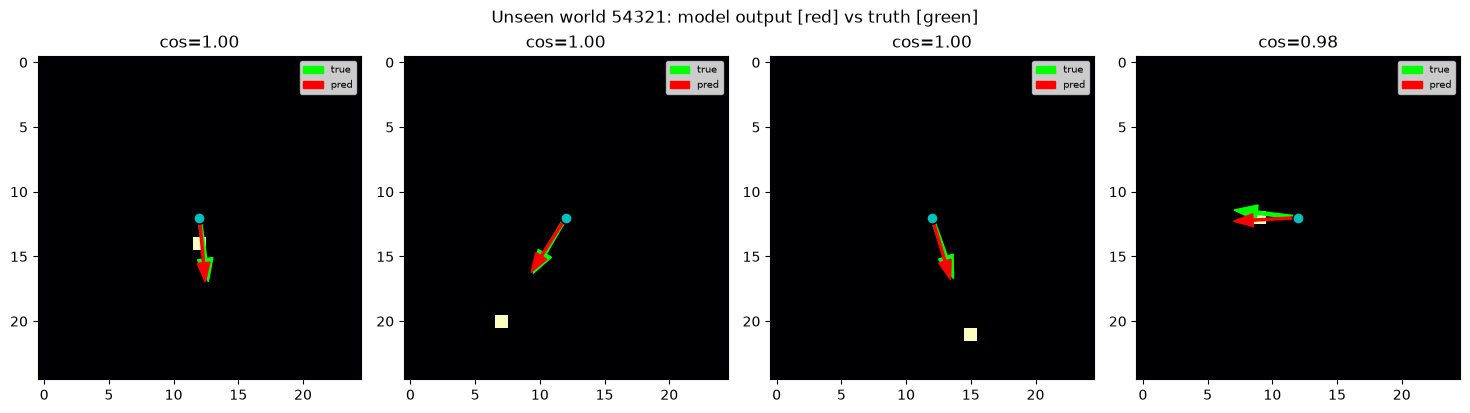

In [8]:
pick = np.random.default_rng(1).choice(len(X), size=min(4, len(X)), replace=False)
c = WIN // 2
fig, axes = plt.subplots(1, len(pick), figsize=(3.7*len(pick), 4))
for a, gi in zip(np.atleast_1d(axes), pick):
    p, tw = pred[gi], toward[gi]
    a.imshow(X[gi, 1], origin="upper", cmap="magma")       # entity channel (sheep)
    a.plot(c, c, "co", ms=8, mec="k")
    a.arrow(c, c, tw[0]*5, tw[1]*5, color="lime", width=0.25, head_width=1.2,
            length_includes_head=True, label="true")
    a.arrow(c, c, p[0]*5, p[1]*5, color="red", width=0.16, head_width=1.0,
            length_includes_head=True, label="pred")
    a.set_title(f"cos={float(p @ tw):.2f}"); a.legend(loc="upper right", fontsize=7)
fig.suptitle(f"Unseen world {VAL_WORLD_SEED}: model output [red] vs truth [green]")
plt.tight_layout(); plt.show()

## Conclusion

Scored on a **world it never trained on** (seed `54321` vs training's `12345`), the saved
`foxvision.pth` still turns its 2-channel egocentric view into a heading that points at the
sheep — high cosine, most scenes within 20°, and the correct heading reliably out-ranks the
wrong ones. The model **generalizes**: it learned to *follow the sheep*, not to memorize a
particular map, and is a valid drop-in for the `Brain.decide(obs) → act` contract.